# 10. Modelos explicativos y relaciones entre variables

Este notebook responde a la consigna de explorar relaciones estructurales entre variables del mercado inmobiliario mediante modelos explicativos.

Desde el modelo de negocio, el objetivo es entender qué atributos ayudan a explicar el precio publicado de una propiedad y cómo esa lectura puede apoyar decisiones de inversión tipo flipper: tasación preliminar, comparación contra propiedades similares, detección de posibles subvaluaciones y priorización de inmuebles para análisis más profundo.

Se comparan dos enfoques:

- **Ridge Regression** como modelo baseline lineal, regularizado e interpretable.
- **Random Forest Regressor** como modelo no lineal basado en árboles, útil para capturar interacciones y comparar importancia de variables.

El target es `Precio`. El objetivo no es construir un tasador final de producción, sino entender qué variables parecen explicar mejor el precio publicado y cómo esos hallazgos pueden apoyar decisiones comerciales.


## Estrategia metodológica

1. Se usa `Argenprop_limpio_con_indices.csv`, que contiene el dataset limpio más los índices PCA/MCA creados en el notebook 9.
2. Se excluyen variables identificatorias o con fuga de información: link, id, calle y `precio_m2`, porque `precio_m2 = Precio / superficie` contiene directamente al target.
3. Se separa train/test con 80/20.
4. Se entrena Ridge como baseline explicativo.
5. Se entrena Random Forest para capturar relaciones no lineales.
6. Se comparan métricas e importancias para interpretar el mercado.

Como el precio tiene distribución asimétrica, ambos modelos se entrenan con transformación logarítmica del target (`log1p(Precio)`) y se evalúan en dólares, luego de volver a la escala original.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
DATA_PATH = "Argenprop_limpio_con_indices.csv"

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
df.head()


Dataset: 7,245 filas x 63 columnas


,sintetica_id_registro,imputada_Precio,imputada_Expensas,original_Calle,original_Altura,imputada_Piso,original_Link,imputada_Ambientes,imputada_Dormitorios,original_Banos,imputada_Estado,imputada_Antiguedad,imputada_Disposicion,imputada_Tipo_Unidad,imputada_Sup_Cubierta_m2,imputada_Sup_Total_m2,sintetica_Aire_acondicionado_individual,sintetica_Losa_radiante,sintetica_Gas_natural,sintetica_Agua_corriente,sintetica_Balcon,sintetica_Terraza,sintetica_Jardin,sintetica_Patio,sintetica_Baulera,sintetica_Cochera,sintetica_Muebles_de_cocina,sintetica_Permite_Mascotas,sintetica_Ascensor,sintetica_Pileta,sintetica_Parrilla,sintetica_Gimnasio,sintetica_Sauna,sintetica_Laundry,sintetica_Vigilancia,enriquecida_Latitud,enriquecida_Longitud,enriquecida_Barrio,enriquecida_Comuna,enriquecida_Dist_Subte_m,enriquecida_Subte_cercano,enriquecida_Linea_subte,enriquecida_Dist_Hospital_m,enriquecida_Hospital_cercano,enriquecida_Dist_Colegio_m,enriquecida_Colegios_500m,enriquecida_Dist_Comisaria_m,enriquecida_Dist_Gimnasio_m,enriquecida_Dist_Supermercado_m,enriquecida_Supermercados_500m,enriquecida_Dist_Avenida_m,enriquecida_Avenida_cercana,enriquecida_Paradas_colectivo_300m,imputada_Antiguedad_imputada,sintetica_Cluster,indice_entorno_integral_pca,indice_servicios_barriales_pca,indice_conectividad_pca,indice_amplitud_pca,indice_lujo_confort_mca,cantidad_amenities,score_antiguedad_nueva,precio_m2
0,1,"150,000.00","260,000.00",Bulnes,"1,600.00",No disponible,https://www.argenprop.com/departamento-en-vent...,3,2,1.00,Excelente,30,Frente,Departamento,60.00,60.00,1,0,1,1,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,-34.59,-58.41,Palermo,14,167.78,BULNES,D,719.19,Dr. J. A. Fernandez,180.35,10,493.13,51.73,20.28,10,156.79,Avenida Santa Fe,19,0,4,83.36,69.76,59.11,16.68,31.23,7,68.97,"2,500.00"
1,2,"330,000.00","203,300.00",ARAOZ,"1,200.00",8,https://www.argenprop.com/departamento-en-vent...,4,3,2.00,Bueno,50,Contrafrente,No disponible,90.00,96.00,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,-34.59,-58.42,Palermo,14,563.73,R.SCALABRINI ORTIZ,D,948.62,R. Gutierrez,188.54,11,403.11,429.58,249.25,4,96.51,Avenida Raúl Scalabrini Ortiz,10,1,4,68.42,46.25,54.72,32.45,25.19,5,45.98,"3,437.50"
2,3,"270,000.00","300,000.00",Honduras,"3,900.00",2,https://www.argenprop.com/departamento-en-vent...,4,2,2.00,Excelente,20,Frente,Semipiso,87.00,87.00,1,0,1,1,1,1,0,0,0,1,1,0,1,0,0,0,0,0,0,-34.58,-58.44,Palermo,14,815.47,MINISTRO CARRANZA - MIGUEL ABUELO,D,"2,930.40",Hospital Municipal de Oncologia M. Curie,240.87,7,891.15,383.02,75.24,7,425.50,Avenida Coronel Niceto Vega,5,0,4,57.05,87.00,30.10,28.00,35.73,8,80.46,"3,103.45"
3,4,"570,000.00","1,000,000.00",Castex,"3,300.00",No disponible,https://www.argenprop.com/departamento-en-vent...,4,3,3.00,No disponible,40,No disponible,Piso,140.00,160.00,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,-34.58,-58.41,Palermo,14,"1,262.25",R.SCALABRINI ORTIZ,D,559.87,Dr. J. A. Fernandez,256.80,4,804.14,286.70,217.08,3,108.44,Avenida Casares,7,0,4,56.75,60.24,63.64,45.85,16.31,4,57.47,"3,562.50"
4,5,"98,000.00","150,000.00",GURRUCHAGA,"2,100.00",5,https://www.argenprop.com/departamento-en-vent...,1,1,1.00,Muy Bueno,15,Frente,No disponible,31.00,34.00,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,-34.59,-58.43,Palermo,14,973.27,PLAZA ITALIA,D,"1,574.57",R. Gutierrez,153.61,5,461.48,393.57,85.29,6,378.80,Avenida Raúl Scalabrini Ortiz,7,0,4,61.15,70.94,46.38,3.17,15.33,3,86.21,"2,882.35"


## Definición de target y variables explicativas

El target es `imputada_Precio`. Se excluyen columnas que no deberían usarse para explicar precio o que producirían fuga de información.

In [2]:
target = "imputada_Precio"

columnas_excluidas = {
    target,
    "precio_m2",                 # fuga: se calcula con Precio
    "original_Link",             # identificador/publicación
    "sintetica_id_registro",     # índice de exportación
    "original_Calle"             # alta cardinalidad; se usa barrio/comuna en su lugar
}

features = [col for col in df.columns if col not in columnas_excluidas]
X = df[features].copy()
y = df[target].copy()

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))
print(categorical_features)


Variables numéricas: 49
Variables categóricas: 9
['imputada_Piso', 'imputada_Estado', 'imputada_Disposicion', 'imputada_Tipo_Unidad', 'enriquecida_Barrio', 'enriquecida_Subte_cercano', 'enriquecida_Linea_subte', 'enriquecida_Hospital_cercano', 'enriquecida_Avenida_cercana']


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (5796, 58) Test: (1449, 58)


## Métricas de evaluación

Se reportan:

- **MAE:** error absoluto promedio en USD. Es la métrica más interpretable comercialmente.
- **RMSE:** penaliza más los errores grandes.
- **MedAE:** error absoluto mediano, robusto a outliers.
- **R²:** proporción de variabilidad explicada en test.
- **MAPE:** error porcentual promedio, con cautela porque puede distorsionarse en propiedades de bajo precio.

In [4]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    errores_abs = np.abs(y_test - pred)
    mape = np.mean(errores_abs / y_test) * 100
    return {
        "modelo": nombre,
        "MAE_USD": mean_absolute_error(y_test, pred),
        "RMSE_USD": mean_squared_error(y_test, pred) ** 0.5,
        "MedAE_USD": np.median(errores_abs),
        "MAPE_%": mape,
        "R2": r2_score(y_test, pred)
    }

def plot_predicho_vs_real(y_test, pred, titulo):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_test, pred, alpha=0.35, s=18)
    lim = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lim, lim, color="red", linestyle="--")
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


## Modelo baseline: Ridge Regression

Ridge es una regresión lineal con regularización L2. Sirve como baseline porque:

- permite evaluar una relación lineal inicial entre variables y precio;
- reduce inestabilidad por multicolinealidad;
- permite interpretar coeficientes;
- funciona bien como punto de comparación contra modelos más flexibles.

Las variables numéricas se imputan y estandarizan. Las categóricas se imputan y codifican con One-Hot Encoding.

In [5]:
numeric_pipeline_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False))
])

preprocess_ridge = ColumnTransformer([
    ("num", numeric_pipeline_ridge, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
], verbose_feature_names_out=False)

ridge_pipeline = Pipeline([
    ("preprocess", preprocess_ridge),
    ("model", RidgeCV(alphas=np.logspace(-2, 4, 25)))
])

ridge_model = TransformedTargetRegressor(
    regressor=ridge_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("Alpha seleccionado por RidgeCV:", ridge_model.regressor_.named_steps["model"].alpha_)
evaluacion_ridge = evaluar_modelo("Ridge baseline", ridge_model, X_test, y_test)
pd.DataFrame([evaluacion_ridge])


Alpha seleccionado por RidgeCV: 10.0


,modelo,MAE_USD,RMSE_USD,MedAE_USD,MAPE_%,R2
0,Ridge baseline,"38,406.08","92,304.48","18,729.73",20.95,0.52


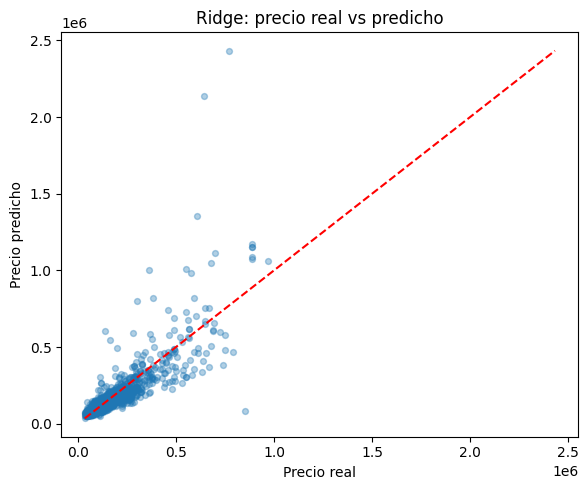

In [6]:
plot_predicho_vs_real(y_test, ridge_pred, "Ridge: precio real vs predicho")


### Interpretación de Ridge

Como Ridge trabaja sobre variables numéricas estandarizadas y dummies categóricas, los coeficientes se interpretan como efectos aproximados sobre `log(Precio)`. En términos prácticos:

- coeficientes positivos: variables asociadas a mayor precio;
- coeficientes negativos: variables asociadas a menor precio;
- la magnitud permite comparar señales, aunque no debe leerse como causalidad.

In [7]:
ridge_inner = ridge_model.regressor_
feature_names_ridge = ridge_inner.named_steps["preprocess"].get_feature_names_out()
coeficientes = ridge_inner.named_steps["model"].coef_

ridge_coef = pd.DataFrame({
    "feature": feature_names_ridge,
    "coef_log_precio": coeficientes,
    "impacto_aprox_%": (np.exp(coeficientes) - 1) * 100
}).sort_values("coef_log_precio", ascending=False)

top_ridge = pd.concat([
    ridge_coef.head(12),
    ridge_coef.tail(12)
])

top_ridge


,feature,coef_log_precio,impacto_aprox_%
108,enriquecida_Barrio_Puerto Madero,0.31,36.33
177,enriquecida_Subte_cercano_PLAZA DE MAYO,0.21,22.95
282,enriquecida_Avenida_cercana_Avenida Pedro Goyena,0.19,21.02
2,imputada_Ambientes,0.15,16.75
7,imputada_Sup_Total_m2,0.15,16.67
300,enriquecida_Avenida_cercana_Azucena Villaflor,0.14,15.05
242,enriquecida_Avenida_cercana_Avenida Cerviño,0.14,14.56
190,enriquecida_Subte_cercano_SANTA FE - CARLOS JA...,0.11,11.91
172,enriquecida_Subte_cercano_PALERMO,0.10,10.39
27,enriquecida_Latitud,0.10,10.25


## Modelo no lineal: Random Forest

Random Forest permite capturar relaciones no lineales e interacciones entre variables, por ejemplo:

- superficie y barrio;
- amenities y tipo de unidad;
- ubicación y cluster;
- antigüedad y estado.

A diferencia de Ridge, no exige una relación lineal estricta. Su interpretación se realiza mediante importancia de variables y comparación de desempeño.

In [8]:
numeric_pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_rf = ColumnTransformer([
    ("num", numeric_pipeline_rf, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
], verbose_feature_names_out=False)

rf_pipeline = Pipeline([
    ("preprocess", preprocess_rf),
    ("model", RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

rf_model = TransformedTargetRegressor(
    regressor=rf_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

evaluacion_rf = evaluar_modelo("Random Forest", rf_model, X_test, y_test)
pd.DataFrame([evaluacion_rf])


,modelo,MAE_USD,RMSE_USD,MedAE_USD,MAPE_%,R2
0,Random Forest,"33,537.93","63,546.85","17,374.33",18.46,0.77


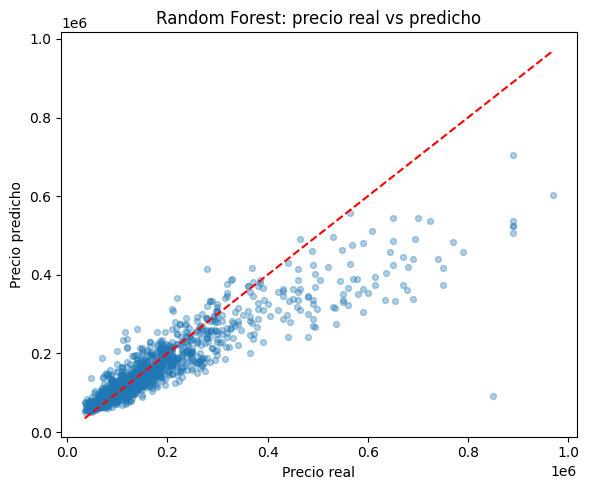

In [9]:
plot_predicho_vs_real(y_test, rf_pred, "Random Forest: precio real vs predicho")


## Comparación de modelos

La comparación permite evaluar si el mercado parece responder a relaciones lineales simples o si hay ganancias claras al usar un modelo no lineal.

In [10]:
comparacion_modelos = pd.DataFrame([evaluacion_ridge, evaluacion_rf])
comparacion_modelos


,modelo,MAE_USD,RMSE_USD,MedAE_USD,MAPE_%,R2
0,Ridge baseline,"38,406.08","92,304.48","18,729.73",20.95,0.52
1,Random Forest,"33,537.93","63,546.85","17,374.33",18.46,0.77


In [11]:
mejora_mae = (comparacion_modelos.loc[0, "MAE_USD"] - comparacion_modelos.loc[1, "MAE_USD"]) / comparacion_modelos.loc[0, "MAE_USD"] * 100
mejora_r2 = comparacion_modelos.loc[1, "R2"] - comparacion_modelos.loc[0, "R2"]

print(f"Reducción de MAE del Random Forest respecto de Ridge: {mejora_mae:.1f}%")
print(f"Mejora absoluta de R²: {mejora_r2:.3f}")


Reducción de MAE del Random Forest respecto de Ridge: 12.7%
Mejora absoluta de R²: 0.254


## Importancia de variables en Random Forest

Se usa **permutation importance** sobre test. Esta técnica mide cuánto empeora el error al permutar una variable. Si el error empeora mucho, la variable aporta información relevante para explicar el precio.

In [12]:
perm_importance = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1
)

importancia_rf = pd.DataFrame({
    "feature": X_test.columns,
    "aumento_MAE_USD": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values("aumento_MAE_USD", ascending=False)

importancia_rf.head(20)


,feature,aumento_MAE_USD,std
11,imputada_Sup_Total_m2,"9,467.29",337.22
10,imputada_Sup_Cubierta_m2,"8,253.77",387.58
54,indice_amplitud_pca,"8,055.92",226.97
0,imputada_Expensas,"7,330.66",357.68
5,original_Banos,"4,536.23",166.60
3,imputada_Ambientes,"2,390.47",199.42
4,imputada_Dormitorios,"2,001.15",191.15
31,enriquecida_Latitud,"1,793.85",182.84
34,enriquecida_Comuna,"1,001.16",63.54
55,indice_lujo_confort_mca,926.53,74.88


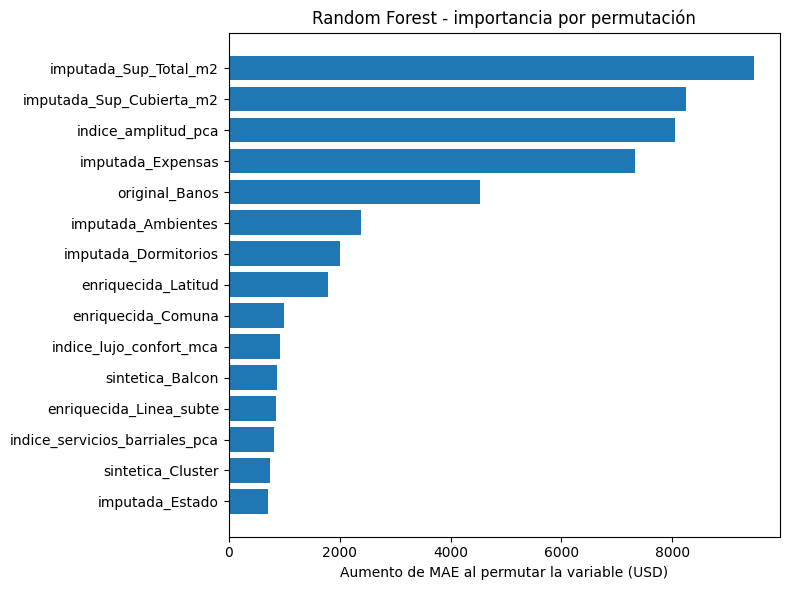

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
top_importancia = importancia_rf.head(15).sort_values("aumento_MAE_USD")
ax.barh(top_importancia["feature"], top_importancia["aumento_MAE_USD"])
ax.set_xlabel("Aumento de MAE al permutar la variable (USD)")
ax.set_title("Random Forest - importancia por permutación")
plt.tight_layout()
plt.show()


## Análisis de sensibilidad

Para conectar el modelo con decisiones de negocio, se revisa cómo cambian las predicciones promedio según algunas variables clave. Este análisis es descriptivo y no causal.

In [14]:
analisis_test = X_test.copy()
analisis_test["precio_real"] = y_test.values
analisis_test["pred_ridge"] = ridge_pred
analisis_test["pred_rf"] = rf_pred

resumen_cluster = (
    analisis_test
    .groupby("sintetica_Cluster")
    .agg(
        propiedades=("precio_real", "size"),
        precio_real_mediano=("precio_real", "median"),
        pred_rf_mediana=("pred_rf", "median"),
        sup_total_mediana=("imputada_Sup_Total_m2", "median"),
        amplitud_mediana=("indice_amplitud_pca", "median"),
        lujo_mediana=("indice_lujo_confort_mca", "median")
    )
    .round(2)
)

resumen_cluster


,propiedades,precio_real_mediano,pred_rf_mediana,sup_total_mediana,amplitud_mediana,lujo_mediana
sintetica_Cluster,,,,,,
0,127,"110,000.00","106,103.92",56.00,15.53,10.61
1,401,"129,000.00","128,940.79",58.00,13.78,11.28
2,156,"162,500.00","149,406.36",65.29,17.33,12.45
3,17,"520,000.00","363,949.64",107.00,26.58,26.48
4,465,"143,000.00","141,127.77",60.00,15.86,11.82
5,283,"89,000.00","90,786.00",54.00,14.06,8.67


In [15]:
analisis_test["rango_amplitud"] = pd.qcut(
    analisis_test["indice_amplitud_pca"],
    q=4,
    labels=["Baja", "Media-baja", "Media-alta", "Alta"],
    duplicates="drop"
)

analisis_test["rango_lujo"] = pd.qcut(
    analisis_test["indice_lujo_confort_mca"],
    q=4,
    labels=["Bajo", "Medio-bajo", "Medio-alto", "Alto"],
    duplicates="drop"
)

display(
    analisis_test.groupby("rango_amplitud", observed=False)
    .agg(propiedades=("precio_real", "size"), precio_real_mediano=("precio_real", "median"), pred_rf_mediana=("pred_rf", "median"))
    .round(2)
)

display(
    analisis_test.groupby("rango_lujo", observed=False)
    .agg(propiedades=("precio_real", "size"), precio_real_mediano=("precio_real", "median"), pred_rf_mediana=("pred_rf", "median"))
    .round(2)
)


,propiedades,precio_real_mediano,pred_rf_mediana
rango_amplitud,,,
Baja,363,"75,000.00","80,682.50"
Media-baja,362,"112,000.00","107,408.18"
Media-alta,363,"144,000.00","143,328.64"
Alta,361,"260,000.00","248,380.75"


,propiedades,precio_real_mediano,pred_rf_mediana
rango_lujo,,,
Bajo,388,"109,000.00","108,168.65"
Medio-bajo,354,"115,000.00","112,758.71"
Medio-alto,346,"133,000.00","134,119.39"
Alto,361,"175,000.00","160,238.32"


## Interpretación final según la consigna

### Qué variables parecen explicar mejor el precio

Los resultados muestran que las variables estructurales de la propiedad tienen el mayor peso explicativo: superficie total, superficie cubierta, índice de amplitud, expensas, baños y ambientes. Esto es consistente con la lógica del mercado: el precio publicado depende fuertemente del tamaño y escala de la unidad.

También aparecen señales relevantes de ubicación y segmento: latitud, comuna, barrio/línea de subte, cluster e índices sintéticos. Esto indica que el precio no se explica solo por metros cuadrados; también importa el contexto territorial y el perfil del barrio.

### Qué aporta Ridge

Ridge funciona como baseline porque entrega una lectura lineal y estable. Permite detectar signos y magnitudes aproximadas de asociación. Su principal limitación es que no captura bien interacciones complejas, por ejemplo que una misma superficie tenga distinto valor según barrio, cluster o dotación de amenities.

### Qué aporta Random Forest

Random Forest mejora el desempeño al capturar relaciones no lineales e interacciones. En términos comerciales, esto sugiere que el mercado inmobiliario no responde a una fórmula lineal simple: el efecto de superficie, amenities, antigüedad o accesibilidad cambia según el segmento territorial.

### Cómo usar estos hallazgos para tomar decisiones

- **Tasación:** priorizar superficie, baños, expensas, barrio/cluster e índices sintéticos como variables base de valuación.
- **Inversión/flipping:** buscar propiedades cuyo precio observado esté por debajo del precio esperado por el modelo, especialmente si tienen buen entorno o margen de mejora.
- **Segmentación comercial:** usar clusters e índices para comparar propiedades contra perfiles similares, no contra todo CABA.
- **Mejora de producto:** amenities e índice de lujo/confort aportan señal, pero su impacto debe evaluarse junto con barrio y tamaño.

Los modelos son explicativos y de apoyo analítico; no reemplazan validación inmobiliaria, costos de obra, negociación ni precios reales de cierre.